# **Analyze all Simulations**

This notebook is for the comparison of all simulations that I ran up to the data of July 7th 2025

## Usage Summary

The `SimulationAnalyzer` class provides comprehensive tools for analyzing HBNM simulation outputs:

### Key Features:
1. **Automatic Detection**: Automatically detects all available simulations and iterations
2. **Batch Loading**: Loads all iteration data for multiple simulations simultaneously
3. **Rich Visualizations**: Creates publication-ready plots showing convergence and parameter evolution
4. **Comparative Analysis**: Compares multiple simulation types side-by-side
5. **Export Functionality**: Saves all plots and summary statistics

### Key Methods:
- `detect_simulations()` - Find all available simulation directories
- `load_all_simulations()` - Load data for all or specified simulations
- `plot_simulation_progress()` - Create comprehensive progress plots
- `plot_parameter_evolution()` - Show parameter evolution with confidence intervals
- `plot_comparative_analysis()` - Compare multiple simulations
- `save_all_plots()` - Export all visualizations and summaries

### Usage Examples:
```python
# Basic usage
from hbnm.analysis import SimulationAnalyzer
from hbnm.io import Data

data = Data(input_dir, output_dir)  
analyzer = SimulationAnalyzer(data)

# Load all available simulations
sim_data = analyzer.load_all_simulations()

# Create plots for a specific simulation
analyzer.plot_simulation_progress('baseline_homogeneous')

# Save everything
analyzer.save_all_plots('./analysis_output/')
```


### **TODO**

Collapse the functionality of: 
- /Users/fdjim/Desktop/HBNM/HBNM/scripts/model_sampling_test.py
- /Users/fdjim/Desktop/HBNM/HBNM/scripts/model_sampling.py

Into a the `analysis.py` Class for a more unified API

### Comprehensive Simulation Analysis

This notebook demonstrates how to use the new `SimulationAnalyzer` class to automatically load all simulation iterations and create comprehensive visualizations.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.io import Data
from hbnm.bnm import Bnm
from hbnm.model.utils import subdiag, fisher_z
from hbnm.analysis import SimulationAnalyzer
from scipy.stats import pearsonr
import os
import pandas as pd

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300


In [29]:
# Initialize data handler and analyzer
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)

input_dir = parent_path + '/data'
output_dir = parent_path + '/outputs'

data = Data(input_dir, output_dir)
analyzer = SimulationAnalyzer(data, verbose=True)

# Define the simulations to analyze
sims = [
# 'Homogenous',
# 'Heterogeneous_Dem_Range',
# 'Heterogeneous_Old_Range',
'NTHC_Homo_Group',
'NTHC_Myelin_Group',
'TEHC_Myelin_Group',
'NTS_Myelin_Group',
'TIS_Myelin_Group',
]

print(f"Target simulations: {sims}")

# Automatically detect available simulations
detected_sims = analyzer.detect_simulations()
print(f"Detected simulations: {detected_sims}")

# Use intersection of target and detected simulations
available_sims = [sim for sim in sims if sim in detected_sims]
print(f"Available simulations for analysis: {available_sims}")

Target simulations: ['NTHC_Homo_Group', 'NTHC_Myelin_Group', 'TEHC_Myelin_Group', 'NTS_Myelin_Group', 'TIS_Myelin_Group']
Detected 19 simulations: ['TIS_Myelin_Group', 'Dopamine_AVG', 'Myelin_NMDA', 'NTS_Myelin_Group', 'D2_like_true', 'Heterogeneous_Dem_Range', 'D2_like_false', 'NMDA_GABA', 'D1_like_true', 'Myelin_GABA', 'Norepinephrine_AVG', 'GABAa_AVG', 'NTHC_Homo_Group', 'NTHC_Myelin_Group', 'Heterogeneous_Old_Range', 'TEHC_Myelin_Group', 'Homogenous', 'NMDA_AVG', 'D1_like_false']
Detected simulations: ['D1_like_false', 'D1_like_true', 'D2_like_false', 'D2_like_true', 'Dopamine_AVG', 'GABAa_AVG', 'Heterogeneous_Dem_Range', 'Heterogeneous_Old_Range', 'Homogenous', 'Myelin_GABA', 'Myelin_NMDA', 'NMDA_AVG', 'NMDA_GABA', 'NTHC_Homo_Group', 'NTHC_Myelin_Group', 'NTS_Myelin_Group', 'Norepinephrine_AVG', 'TEHC_Myelin_Group', 'TIS_Myelin_Group']
Available simulations for analysis: ['NTHC_Homo_Group', 'NTHC_Myelin_Group', 'TEHC_Myelin_Group', 'NTS_Myelin_Group', 'TIS_Myelin_Group']


In [30]:
# Load all simulation data automatically
print("Loading all simulation data...")
all_simulation_data = analyzer.load_all_simulations(available_sims)

# Display summary of loaded data
print("\n" + "="*60)
print("DATA LOADING SUMMARY")
print("="*60)

for sim_name, sim_data in all_simulation_data.items():
    if sim_data['iterations']:
        print(f"\n{sim_name.upper()}:")
        print(f"  • Iterations: {len(sim_data['iterations'])} ({min(sim_data['iterations'])}-{max(sim_data['iterations'])})")
        print(f"  • Parameters: {sim_data['theta'][0].shape[0]}")
        print(f"  • Particles per iteration: {sim_data['theta'][0].shape[1]}")
        print(f"  • Final acceptance rate: {sim_data['acceptance_rate'][-1]:.1%}")
        print(f"  • Final epsilon: {sim_data['epsilon'][-1]:.4f}")
        print(f"  • Best distance achieved: {min([np.min(d) for d in sim_data['distances']]):.4f}")
    else:
        print(f"\n{sim_name.upper()}: No data loaded")

Loading all simulation data...

Loading simulation: NTHC_Homo_Group
Simulation 'NTHC_Homo_Group': found 31 iterations (1-31)
Loaded 31 iterations for NTHC_Homo_Group

Loading simulation: NTHC_Myelin_Group
Simulation 'NTHC_Myelin_Group': found 51 iterations (1-51)
Loaded 51 iterations for NTHC_Myelin_Group

Loading simulation: TEHC_Myelin_Group
Simulation 'TEHC_Myelin_Group': found 50 iterations (1-50)
Loaded 50 iterations for TEHC_Myelin_Group

Loading simulation: NTS_Myelin_Group
Simulation 'NTS_Myelin_Group': found 50 iterations (1-50)
Loaded 50 iterations for NTS_Myelin_Group

Loading simulation: TIS_Myelin_Group
Simulation 'TIS_Myelin_Group': found 1 iterations (1-1)
Loaded 1 iterations for TIS_Myelin_Group

DATA LOADING SUMMARY

NTHC_HOMO_GROUP:
  • Iterations: 31 (1-31)
  • Parameters: 3
  • Particles per iteration: 100
  • Final acceptance rate: 1.0%
  • Final epsilon: 0.3818
  • Best distance achieved: 0.3798

NTHC_MYELIN_GROUP:
  • Iterations: 51 (1-51)
  • Parameters: 5
  • P

In [31]:
# Create summary report
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY REPORT")
print("="*60)

summary_df = analyzer.create_summary_report(available_sims)
print(summary_df.to_string(index=False))

# Save summary to CSV
summary_df.to_csv(f"{output_dir}/simulation_summary.csv", index=False)
print(f"\nSummary saved to: {output_dir}/simulation_summary.csv")


COMPREHENSIVE SUMMARY REPORT
       Simulation  Iterations  Parameters Final_Acceptance_Rate Final_Epsilon Final_ESS Best_Distance Final_Distance Number of Samples Description
  NTHC_Homo_Group          31           3                  1.0%        0.3818      89.8        0.3798         0.3799               100     Unknown
NTHC_Myelin_Group          51           5                 20.1%        0.3534      82.2        0.3532         0.3532               100     Unknown
TEHC_Myelin_Group          50           5                 17.2%        0.3614      89.6        0.3609         0.3609               100     Unknown
 NTS_Myelin_Group          50           5                 21.3%        0.3674      77.8        0.3670         0.3671               100     Unknown
 TIS_Myelin_Group           1           5                 98.0%        0.4797     100.0        0.3870         0.3870               100     Unknown

Summary saved to: /home/frank/HBNM/outputs/simulation_summary.csv



CREATING INDIVIDUAL SIMULATION PLOTS

Creating progress plot for NTHC_Homo_Group...


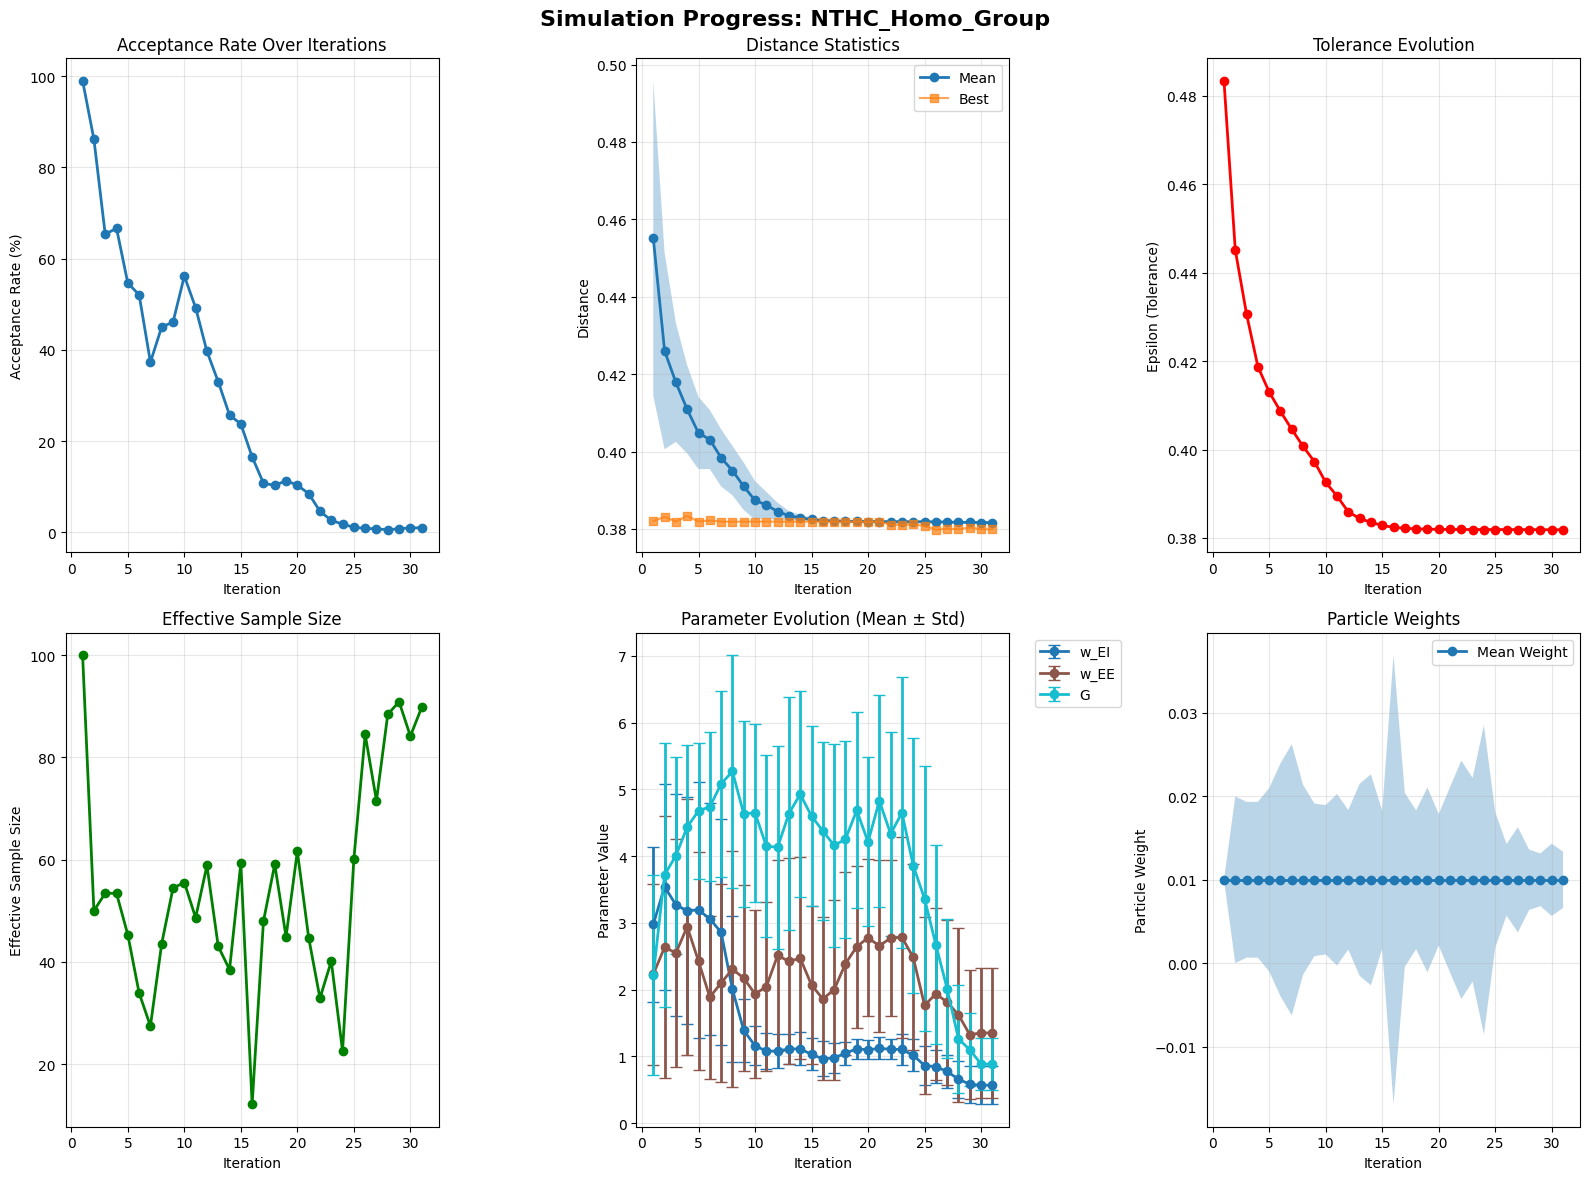


Creating progress plot for NTHC_Myelin_Group...


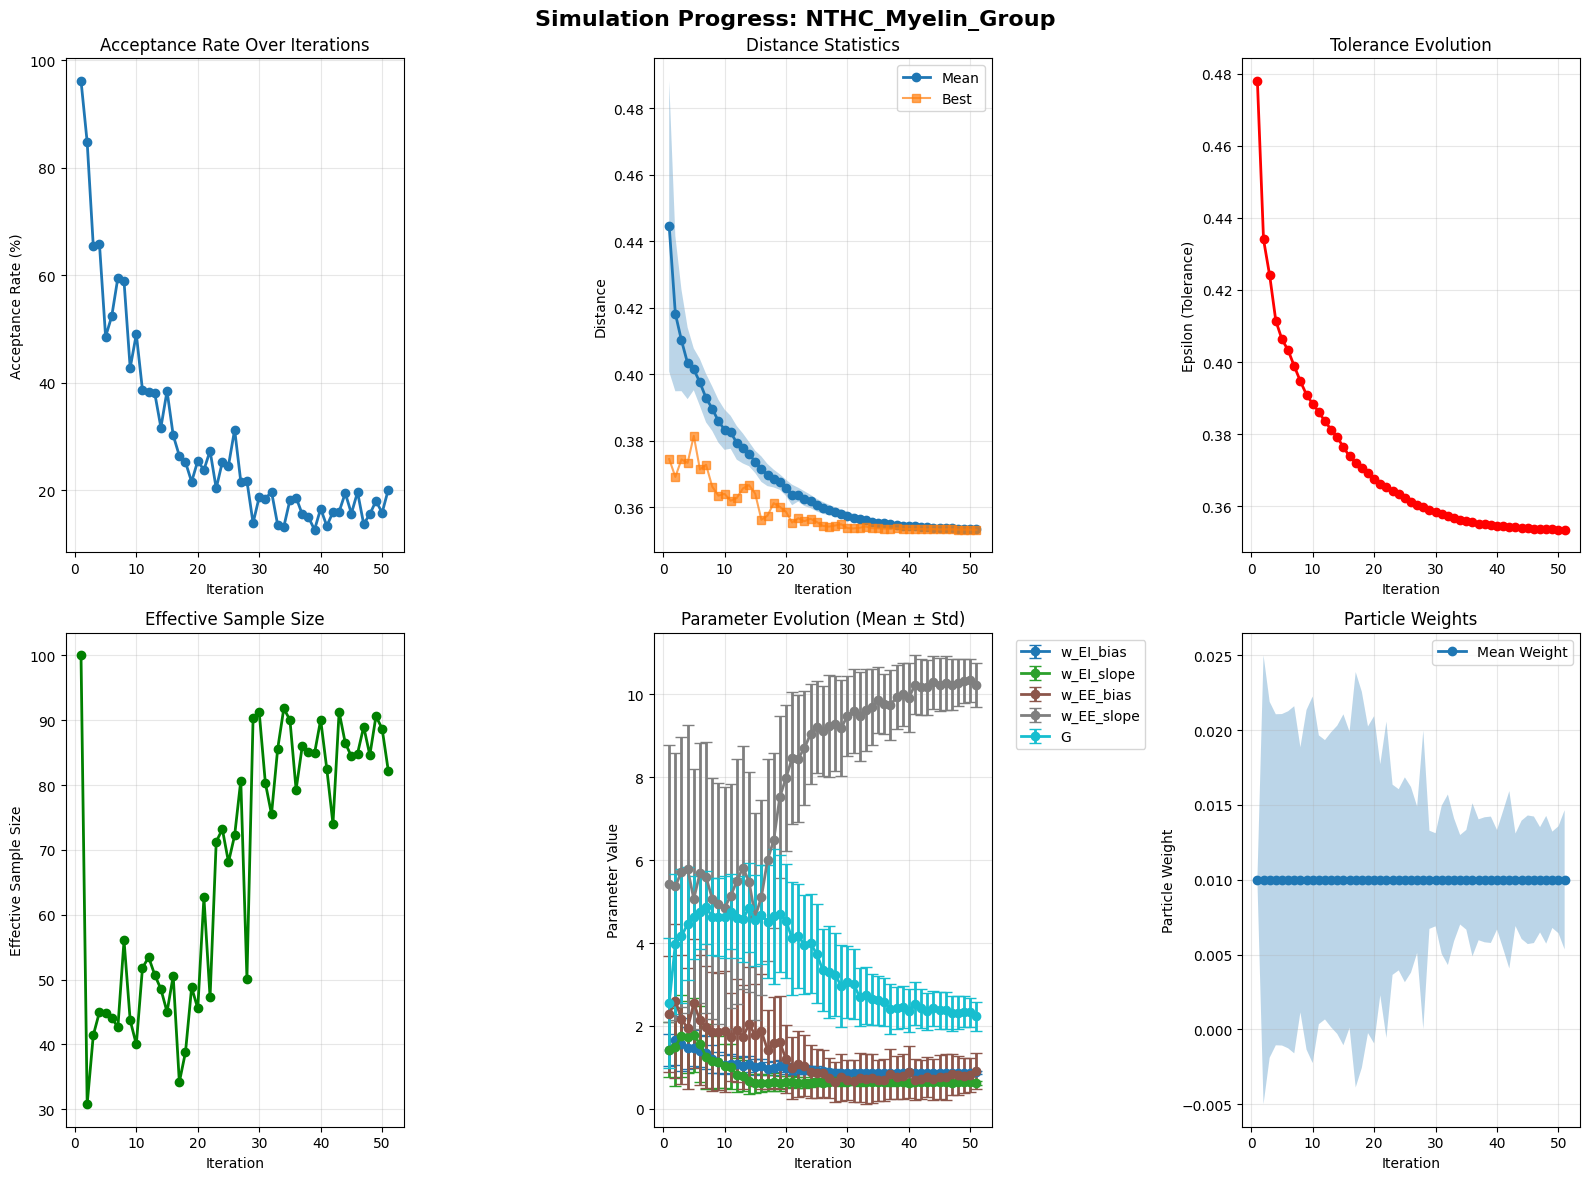


Creating progress plot for TEHC_Myelin_Group...


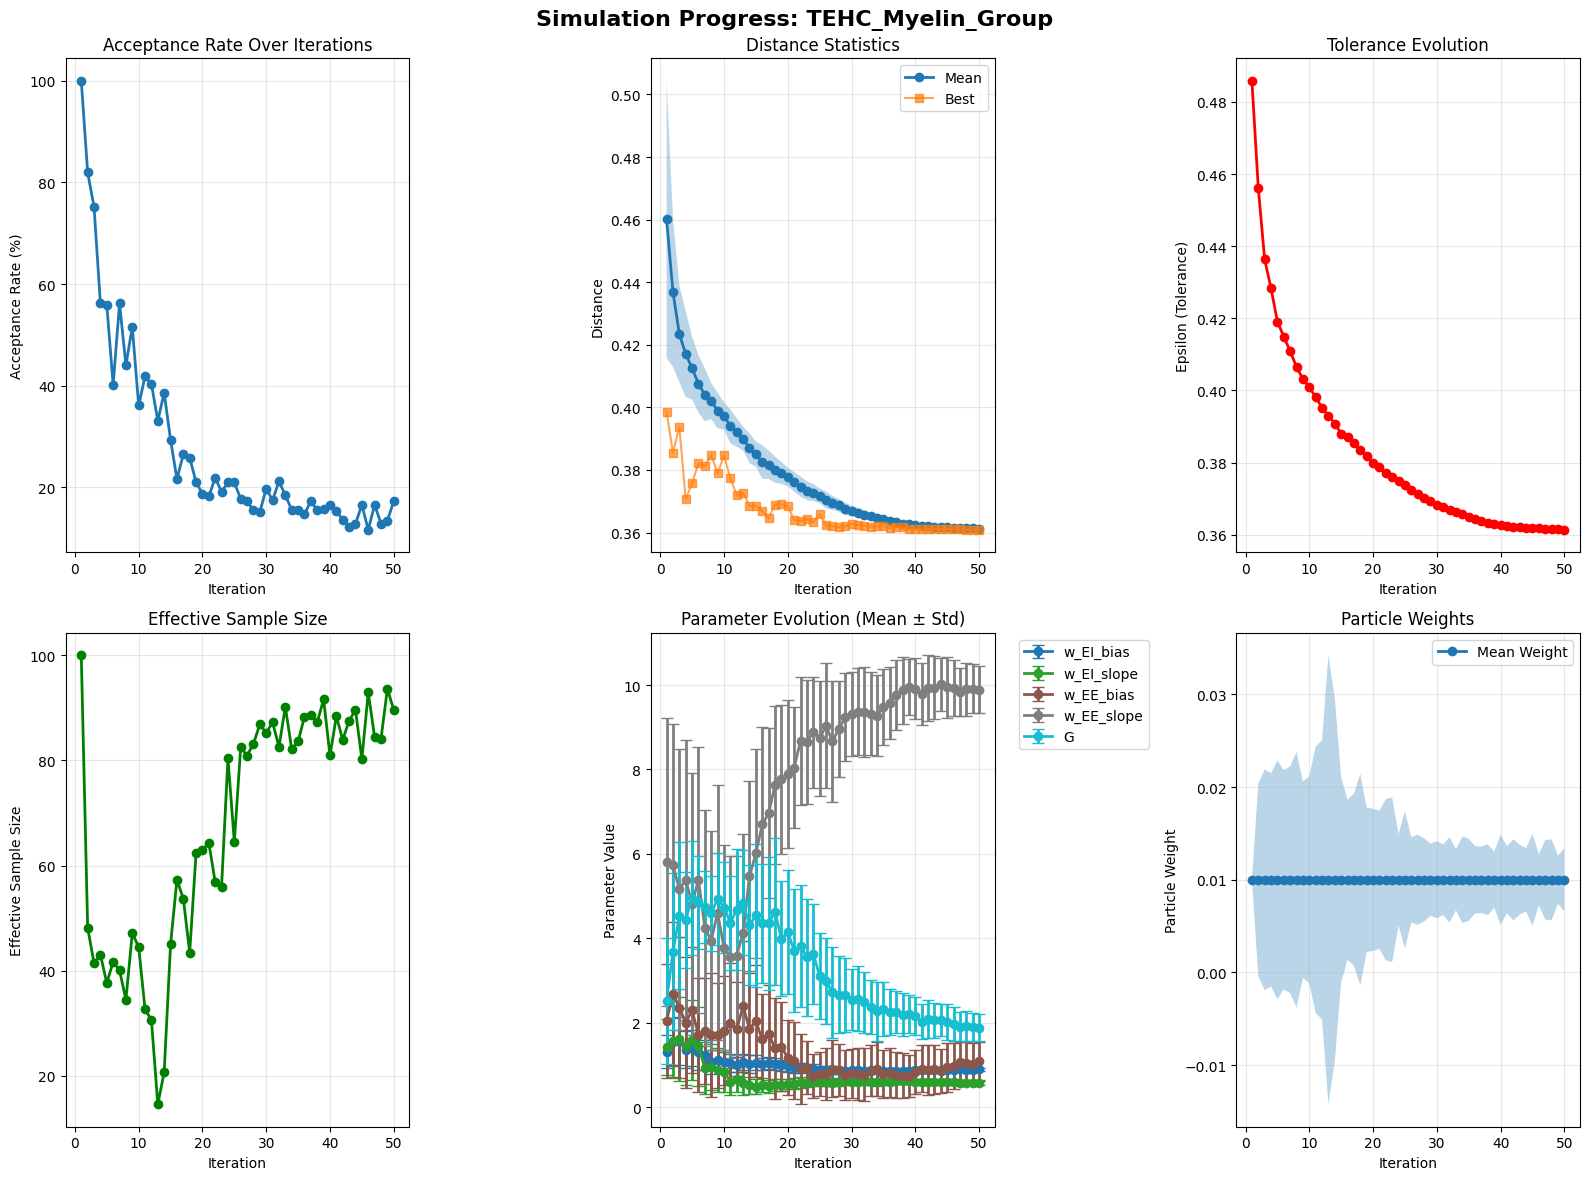


Creating progress plot for NTS_Myelin_Group...


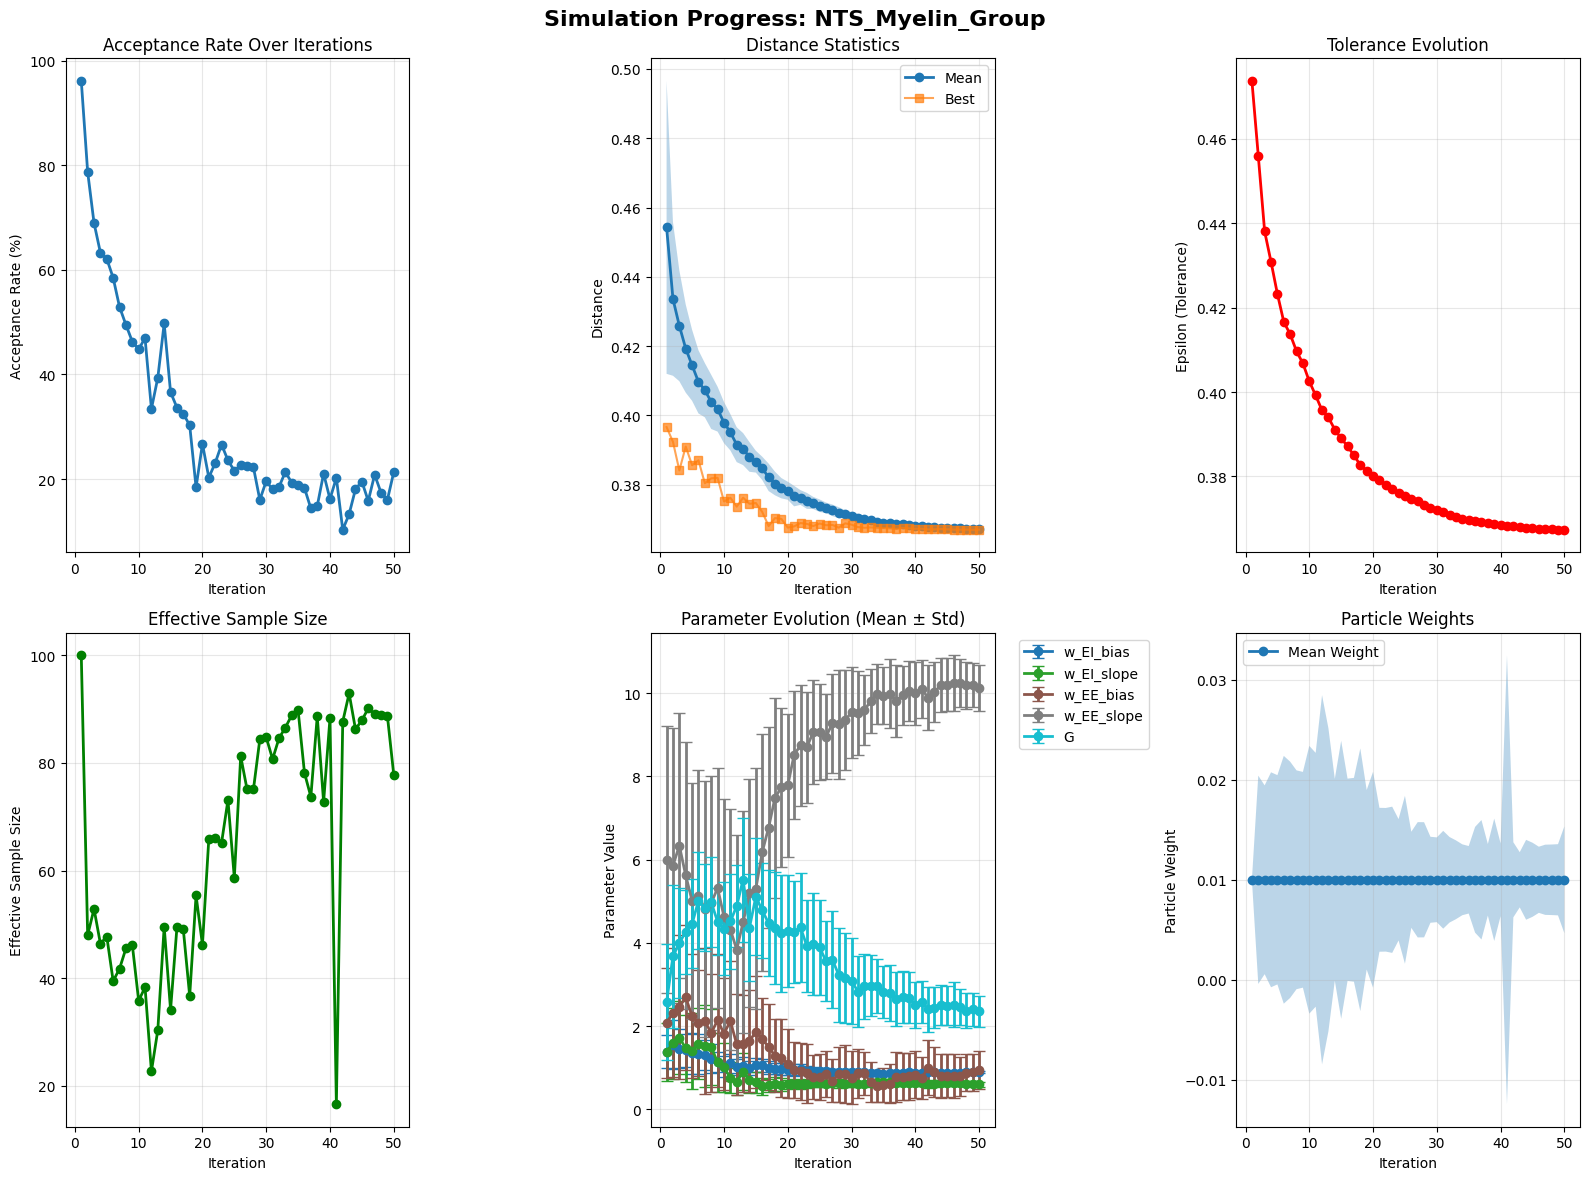


Creating progress plot for TIS_Myelin_Group...


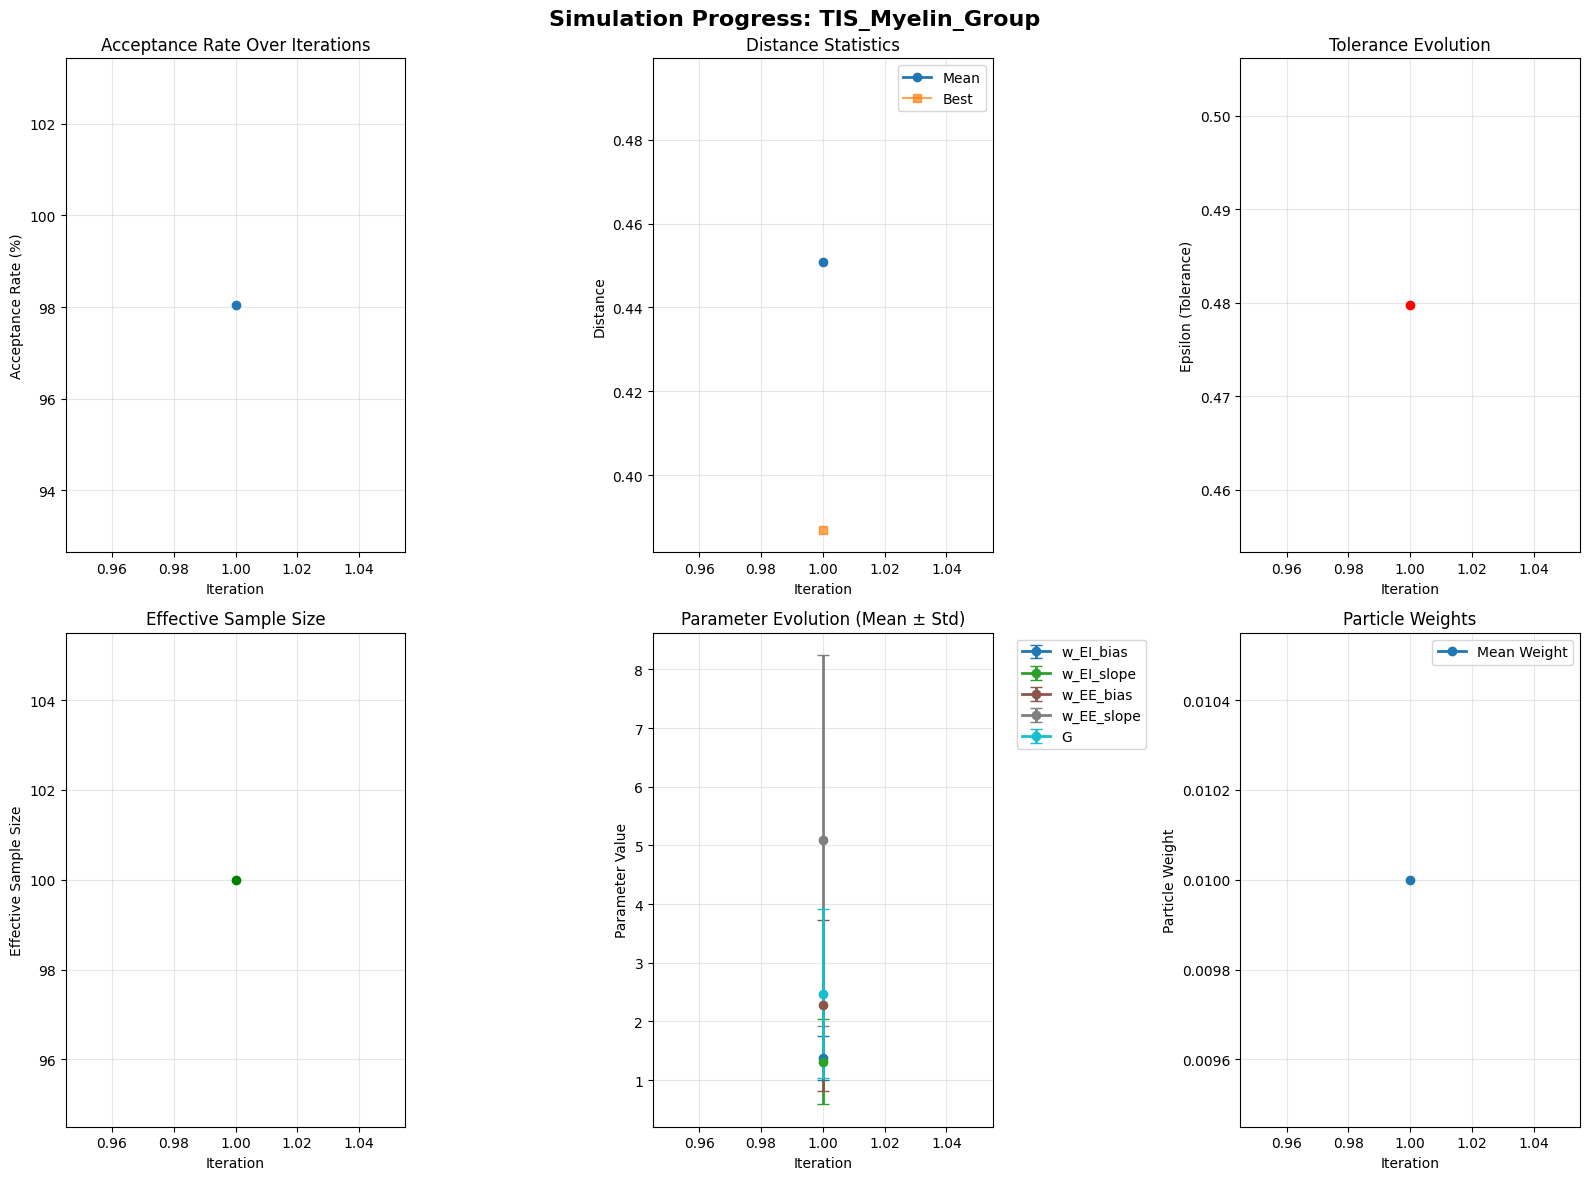

In [32]:
# Create individual simulation progress plots
print("\n" + "="*60)
print("CREATING INDIVIDUAL SIMULATION PLOTS")
print("="*60)

for sim_name in available_sims:
    print(f"\nCreating progress plot for {sim_name}...")
    fig = analyzer.plot_simulation_progress(sim_name, figsize=(16, 12))
    if fig is not None:
        plt.show()
        # You can save the figure if needed:
        # fig.savefig(f'{output_dir}/{sim_name}_progress.png', dpi=300, bbox_inches='tight')
    else:
        print(f"No plot could be created for {sim_name}")


In [33]:
# # Create detailed parameter evolution plots
# print("\n" + "="*60)
# print("CREATING PARAMETER EVOLUTION PLOTS")
# print("="*60)

# for sim_name in available_sims:
#     print(f"\nCreating parameter evolution plot for {sim_name}...")
#     fig = analyzer.plot_parameter_evolution(sim_name, figsize=(14, 10))
#     if fig is not None:
#         plt.show()
#         # You can save the figure if needed:
#         # fig.savefig(f'{output_dir}/{sim_name}_parameters.png', dpi=300, bbox_inches='tight')
#     else:
#         print(f"No parameter plot could be created for {sim_name}")



CREATING COMPARATIVE ANALYSIS
Creating comparative plot across all simulations...


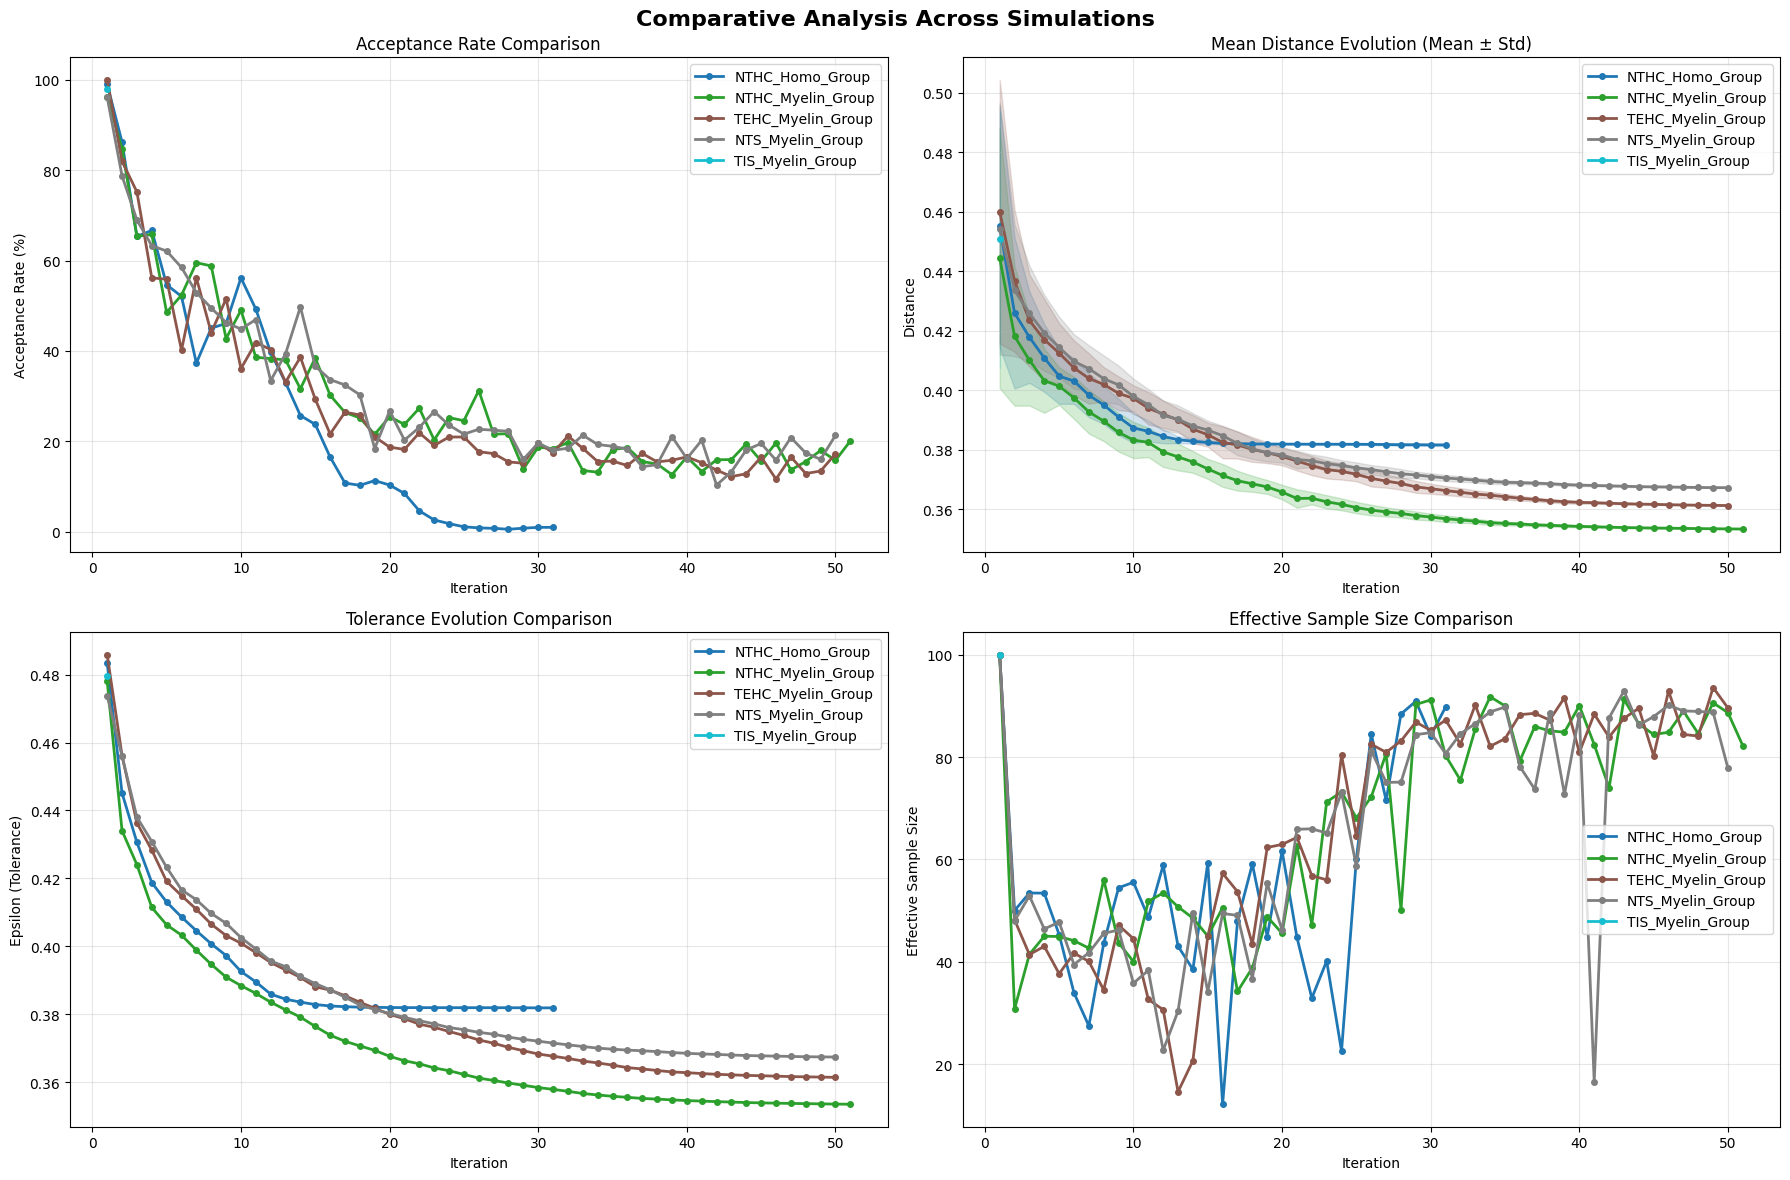

In [34]:
# Create comparative analysis across all simulations
if len(available_sims) > 1:
    print("\n" + "="*60)
    print("CREATING COMPARATIVE ANALYSIS")
    print("="*60)
    
    print("Creating comparative plot across all simulations...")
    fig = analyzer.plot_comparative_analysis(available_sims, figsize=(18, 12))
    if fig is not None:
        plt.show()
        # You can save the figure if needed:
        # fig.savefig(f'{output_dir}/comparative_analysis.png', dpi=300, bbox_inches='tight')
    else:
        print("No comparative plot could be created")
else:
    print("\nSkipping comparative analysis (need at least 2 simulations)")


In [35]:
# # Save all plots and reports to a dedicated analysis folder
# print("\n" + "="*60)
# print("SAVING ALL PLOTS AND REPORTS")
# print("="*60)

# analysis_output_dir = f"{output_dir}/analysis_results"
# analyzer.save_all_plots(analysis_output_dir, available_sims)

# print(f"\nAll analysis results saved to: {analysis_output_dir}")
# print("Files created:")
# print("  • simulation_summary.csv - Summary statistics")
# print("  • [simulation]_progress.png - Progress plots for each simulation")
# print("  • [simulation]_parameters.png - Parameter evolution plots")
# print("  • comparative_analysis.png - Cross-simulation comparison")


In [36]:
# Example: Access specific simulation data for custom analysis
print("\n" + "="*60)
print("EXAMPLE: ACCESSING SPECIFIC DATA")
print("="*60)

# Example of how to access specific simulation data
if 'baseline_myelin_nmda' in available_sims:
    sim_name = 'baseline_myelin_nmda'
    sim_data = all_simulation_data[sim_name]
    
    print(f"Example analysis for {sim_name}:")
    print(f"• Total iterations: {len(sim_data['iterations'])}")
    print(f"• Final iteration: {sim_data['iterations'][-1]}")
    print(f"• Parameter evolution:")
    
    # Get parameter statistics
    param_stats = analyzer.get_parameter_statistics(sim_name)
    final_params = param_stats['theta_means'][-1]  # Final iteration means
    
    for i, param_name in enumerate(param_stats['param_names']):
        print(f"  - {param_name}: {final_params[i]:.4f}")
    
    print(f"• Convergence metrics:")
    print(f"  - Final acceptance rate: {sim_data['acceptance_rate'][-1]:.1%}")
    print(f"  - Final effective sample size: {sim_data['ess'][-1]:.1f}")
    print(f"  - Best distance: {min([np.min(d) for d in sim_data['distances']]):.4f}")
else:
    print("baseline_myelin_nmda not available - showing available simulations instead:")
    for sim_name in available_sims:
        print(f"• {sim_name}: {len(all_simulation_data[sim_name]['iterations'])} iterations")



EXAMPLE: ACCESSING SPECIFIC DATA
baseline_myelin_nmda not available - showing available simulations instead:
• NTHC_Homo_Group: 31 iterations
• NTHC_Myelin_Group: 51 iterations
• TEHC_Myelin_Group: 50 iterations
• NTS_Myelin_Group: 50 iterations
• TIS_Myelin_Group: 1 iterations


### **Explore Parameter Distributions**



### **Correlations with FC**

For each run, check the correlation with FC of the mean, median and best parameter combination